# Project: Supervised learning: predicting customer activity

In this work, I plan to increase the activity of regular customers of the “One Click” online store through personalized offers. To do this, a model will be built that predicts the likelihood of a decline in purchasing activity over a three-month horizon, the results will be combined with data on customer profitability, and then segmentation will be performed to prepare targeted measures. The attributes will be structured in four areas: communication with the client, product behavior, behavior on the website and financial behavior.

Work plan step by step

Step 1. Download data
- Download the necessary datasets and check their compliance with the description.

Step 2. Data preprocessing
- Reduce data to correct types, handle gaps and anomalies, prepare target feature and clear categories.

Step 3: Exploratory Data Analysis
- Study distributions and key dependencies, assess class balance and identify customers with sufficient purchase history.

Step 4. Joining tables
- Combine sources into a single showcase and create a convenient representation of periods for subsequent modeling.

Step 5: Correlation Analysis
- Analyze the relationships of quantitative characteristics, assess multicollinearity and, if necessary, adjust the set of characteristics.

Step 6: Modeling with Pipelines
- Build a feature preparation pipeline, train several classification algorithms, select hyperparameters and select a metric for comparing models.

Step 7. Feature importance analysis
- Assess the contribution of features to the final model using interpretable methods and formulate conclusions about the significance of factors for business and modeling.

Step 8. Buyer segmentation and offers
- Perform segmentation taking into account the predicted probability of a decrease in activity and profitability, select a priority segment, analyze it and prepare personalized recommendations for increasing activity.

##  Loading Data

In [1]:
!pip install shap

In [2]:
!pip install -U scikit-learn

In [3]:
pip install phik

Note: you may need to restart the kernel to use updated packages.


In [100]:
# download all the necessary libraries and modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler, MinMaxScaler, RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import f1_score, recall_score, precision_score, roc_auc_score, fbeta_score, make_scorer
from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
import warnings
import shap
from phik import phik_matrix
from sklearn.dummy import DummyClassifier

In [5]:
warnings.filterwarnings('ignore')

In [6]:
# download a file with data about buyer behavior on the site and print its first 10 lines
market_file = pd.read_csv('/datasets/market_file.csv')
market_file = market_file.rename(columns={ 'длительность': 'duration', 'страниц_за_визит': 'pages_per_visit', 'тип_сервиса': 'service_type' })
market_file.head(10)

,id,Покупательская активность,Тип сервиса,Разрешить сообщать,Маркет_актив_6_мес,Маркет_актив_тек_мес,Длительность,Акционные_покупки,Популярная_категория,Средний_просмотр_категорий_за_визит,Неоплаченные_продукты_штук_квартал,Ошибка_сервиса,Страниц_за_визит
0,215348,Снизилась,премиум,да,3.4,5,121,0.00,Товары для детей,6,2,1,5
1,215349,Снизилась,премиум,да,4.4,4,819,0.75,Товары для детей,4,4,2,5
2,215350,Снизилась,стандартт,нет,4.9,3,539,0.14,Домашний текстиль,5,2,1,5
3,215351,Снизилась,стандартт,да,3.2,5,896,0.99,Товары для детей,5,0,6,4
4,215352,Снизилась,стандартт,нет,5.1,3,1064,0.94,Товары для детей,3,2,3,2
5,215353,Снизилась,стандартт,да,3.3,4,762,0.26,Домашний текстиль,4,1,1,4
6,215354,Снизилась,стандартт,да,5.1,3,431,0.23,Косметика и аксесуары,2,3,7,2
7,215355,Снизилась,стандартт,нет,4.7,4,284,0.17,Товары для детей,5,1,6,4
8,215356,Снизилась,стандартт,да,4.2,4,192,0.14,Косметика и аксесуары,2,2,1,3
9,215357,Снизилась,стандартт,да,3.9,5,154,0.00,Техника для красоты и здоровья,3,3,9,5


In [7]:
# Let's download a dataset about revenue from one customer for all time and print its first 10 lines
market_money = pd.read_csv('/datasets/market_money.csv')
market_money.head(10)

,id,Период,Выручка
0,215348,препредыдущий_месяц,0.0
1,215348,текущий_месяц,3293.1
2,215348,предыдущий_месяц,0.0
3,215349,препредыдущий_месяц,4472.0
4,215349,текущий_месяц,4971.6
5,215349,предыдущий_месяц,5216.0
6,215350,препредыдущий_месяц,4826.0
7,215350,текущий_месяц,5058.4
8,215350,предыдущий_месяц,5457.5
9,215351,текущий_месяц,6610.4


In [8]:
# Let's download a dataset about the time spent by the user on the site and print its first 10 lines
market_time = pd.read_csv('/datasets/market_time.csv')
market_time = market_time.rename(columns={ 'минут': 'minutes', 'период': 'period' })
market_time.head(10)

,id,Период,минут
0,215348,текущий_месяц,14
1,215348,предыдцщий_месяц,13
2,215349,текущий_месяц,10
3,215349,предыдцщий_месяц,12
4,215350,текущий_месяц,13
5,215350,предыдцщий_месяц,8
6,215351,текущий_месяц,13
7,215351,предыдцщий_месяц,11
8,215352,текущий_месяц,11
9,215352,предыдцщий_месяц,8


In [9]:
# Let's download a dataset about the average monthly revenue from each customer and print its first 10 lines
money = pd.read_csv('/datasets/money.csv', sep=';')
money = money.rename(columns={ 'прибыль': 'profit' })
money.head(10)

,id,Прибыль
0,215348,"0,98"
1,215349,"4,16"
2,215350,"3,13"
3,215351,"4,87"
4,215352,"4,21"
5,215353,"3,95"
6,215354,"3,62"
7,215355,"5,26"
8,215356,"4,93"
9,215357,"4,66"


Let's study information about datasets

In [10]:
market_file.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1300 entries, 0 to 1299
Data columns (total 13 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   id                                   1300 non-null   int64  
 1   Покупательская активность            1300 non-null   object 
 2   Тип сервиса                          1300 non-null   object 
 3   Разрешить сообщать                   1300 non-null   object 
 4   Маркет_актив_6_мес                   1300 non-null   float64
 5   Маркет_актив_тек_мес                 1300 non-null   int64  
 6   Длительность                         1300 non-null   int64  
 7   Акционные_покупки                    1300 non-null   float64
 8   Популярная_категория                 1300 non-null   object 
 9   Средний_просмотр_категорий_за_визит  1300 non-null   int64  
 10  Неоплаченные_продукты_штук_квартал   1300 non-null   int64  
 11  Ошибка_сервиса                

In [11]:
market_money.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id       3900 non-null   int64  
 1   Период   3900 non-null   object 
 2   Выручка  3900 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 91.5+ KB


In [12]:
market_time.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2600 entries, 0 to 2599
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      2600 non-null   int64 
 1   Период  2600 non-null   object
 2   минут   2600 non-null   int64 
dtypes: int64(2), object(1)
memory usage: 61.1+ KB


In [13]:
money.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1300 entries, 0 to 1299
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   id       1300 non-null   int64 
 1   Прибыль  1300 non-null   object
dtypes: int64(1), object(1)
memory usage: 20.4+ KB


###Conclusion:
There are no gaps in the data in all tables.

## Data preprocessing

### Renaming Columns

In [14]:
market_file.columns = market_file.columns.str.replace(' ', '_').str.lower()
# replace the spaces with underscores according to PEP8 and make the letters lowercase


In [15]:
market_money.columns = market_money.columns.str.lower()
# make the letters lowercase


In [16]:
market_time.columns = market_time.columns.str.lower()
# make the letters lowercase


In [17]:
money.columns = money.columns.str.lower()
# make the letters lowercase


### Checking data for duplicates

In [18]:
market_file.duplicated().sum()

0

In [19]:
market_money.duplicated().sum()

0

In [20]:
market_time.duplicated().sum()

0

In [21]:
money.duplicated().sum()

0

There are no obvious duplicates. Let's examine the data for implicit duplicates

In [22]:
market_file['service_type'].unique()
# implicit duplicates found in column 'service_type'


array(['премиум', 'стандартт', 'стандарт'], dtype=object)

In [23]:
market_file['service_type'] = market_file['service_type'].str.replace('стандартт', 'стандарт')
# get rid of implicit duplicates


In [24]:
market_time['period'].unique()
# There are no duplicates, but there is a typo, we will correct it


array(['текущий_месяц', 'предыдцщий_месяц'], dtype=object)

In [25]:
market_time['period'] = market_time['period'].str.replace('предыдцщий_месяц', 'предыдущий_месяц')

### Data type checking

In [26]:
market_file.dtypes

id                                       int64
покупательская_активность               object
тип_сервиса                             object
разрешить_сообщать                      object
маркет_актив_6_мес                     float64
маркет_актив_тек_мес                     int64
длительность                             int64
акционные_покупки                      float64
популярная_категория                    object
средний_просмотр_категорий_за_визит      int64
неоплаченные_продукты_штук_квартал       int64
ошибка_сервиса                           int64
страниц_за_визит                         int64
dtype: object

In [27]:
# Let's change the data type in the 'duration' column to float for further analysis
market_file['duration'] = market_file['duration'].astype('float')

In [28]:
# Let's change the data type in the 'pages_per_visit' column to float for further analysis
market_file['pages_per_visit'] = market_file['pages_per_visit'].astype('float')

In [29]:
# Let's change the data type in the 'minutes' column to float for further analysis
market_time['minutes'] = market_time['minutes'].astype('float')

In [30]:
market_money.dtypes

id           int64
период      object
выручка    float64
dtype: object

In [31]:
market_time.dtypes

id          int64
период     object
минут     float64
dtype: object

In [32]:
money.dtypes

id          int64
прибыль    object
dtype: object

In the “profit” column of the money dataframe, the data type is object, although there are numeric data there that are separated by a comma instead of a period, let’s fix this

In [33]:
money['profit'] = money['profit'].str.replace(',', '.')
money['profit'] = money['profit'].astype('float')
# replace the comma with a dot and change the data type to float


###Conclusion:
During data preprocessing:
- I changed the column names in snake_case style, replacing spaces with underscores and converting everything to lower case;
- removed implicit duplicates in the 'service_type' column of the market_file dataframe and a typo in the 'period' column of the market_time dataframe;
- replaced the comma with a dot in the 'profit' column of the money dataframe and changed the data type to float. 

No other problems were found in the data

## Exploratory data analysis

### Creating Functions for Analysis

In [34]:
market_file = market_file.set_index('id')
market_money = market_money.set_index('id')
market_time = market_time.set_index('id')
money = money.set_index('id')

In [35]:
# create a function that builds a histogram and a statistical description of the column for quantitative data,
# for qualitative ones - bar and pie charts

def analyze_distribution(data, column):
    num_columns_data = data.select_dtypes(include='float').columns.to_list()
    cat_columns_data = data.select_dtypes(exclude='float').columns.to_list()
    name = column.replace('_', ' ').capitalize()
    
    if column in num_columns_data:
        data[column].hist(bins=10, color='#F5C6AA')

        plt.xlabel(name)
        plt.ylabel('Number of clients')
        plt.title(f'Распределение колонки "{name}"')  # removed extra quote
        plt.show()

        print(data[column].describe())
    
    else:
        counts = data[column].value_counts()
        counts.plot(kind='bar', color='#F5C6AA')
        plt.xlabel(name)
        plt.ylabel('Number of clients')
        plt.title(f'Распределение колонки "{name}"')
        plt.show()
        plt.pie(
        counts,
        labels=counts.index,
        autopct='%.1f%%')
        plt.title(f'Процентное соотношение колонки "{name}"')
        plt.show()

In [36]:
data_list = [market_file, market_money, market_time, money]
# create a list with the names of dataframes


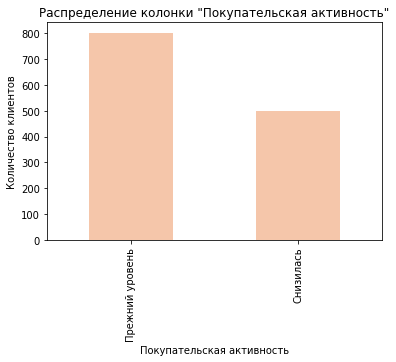

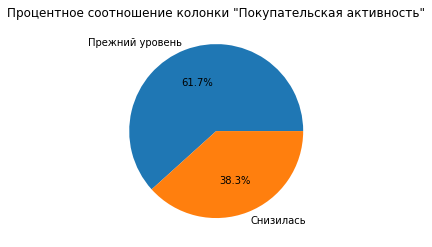

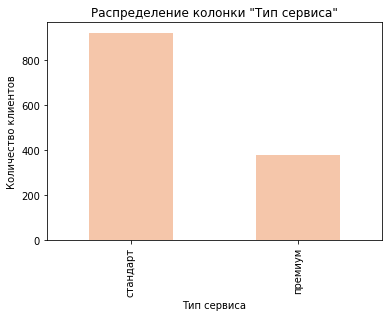

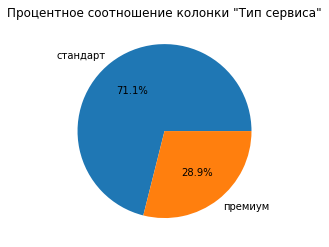

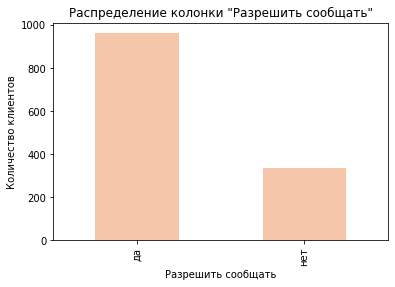

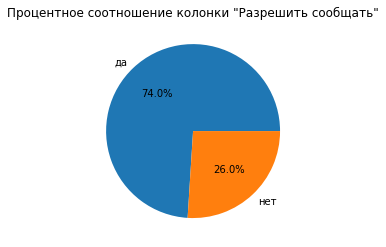

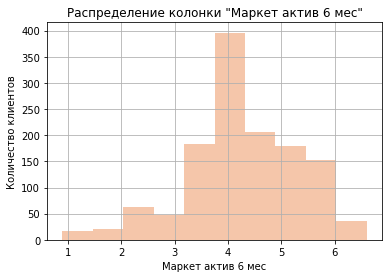

count    1300.000000
mean        4.253769
std         1.014814
min         0.900000
25%         3.700000
50%         4.200000
75%         4.900000
max         6.600000
Name: маркет_актив_6_мес, dtype: float64


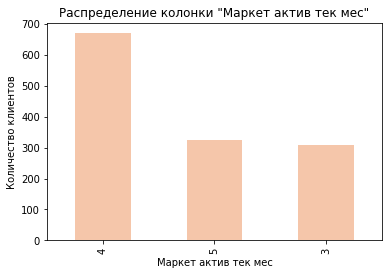

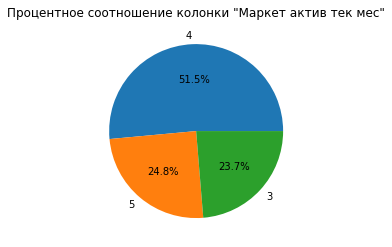

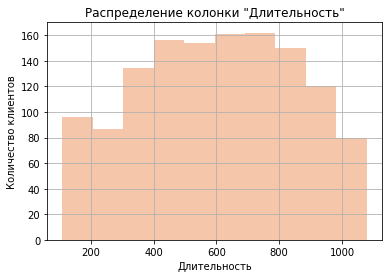

count    1300.000000
mean      601.898462
std       249.856289
min       110.000000
25%       405.500000
50%       606.000000
75%       806.000000
max      1079.000000
Name: длительность, dtype: float64


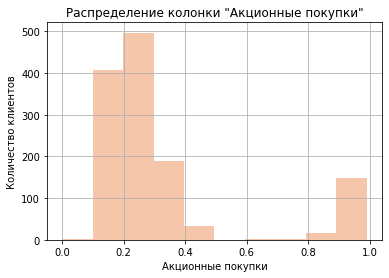

count    1300.000000
mean        0.319808
std         0.249843
min         0.000000
25%         0.170000
50%         0.240000
75%         0.300000
max         0.990000
Name: акционные_покупки, dtype: float64


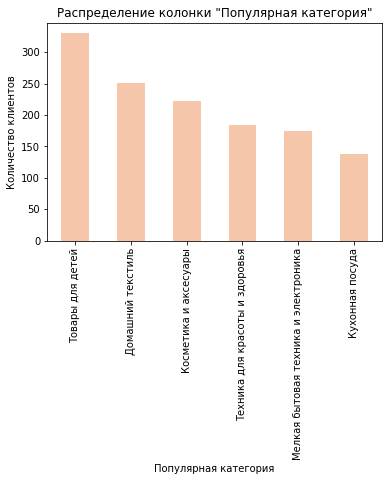

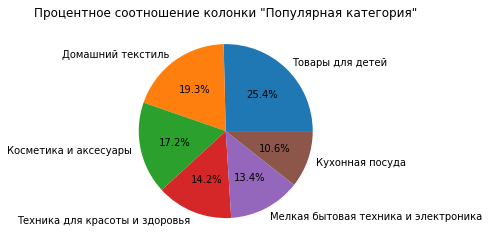

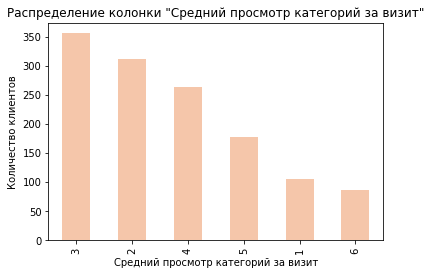

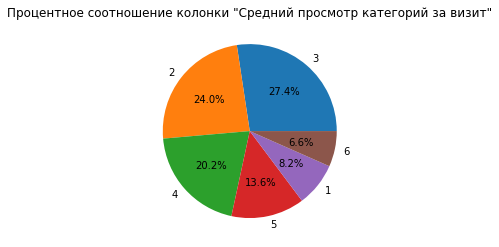

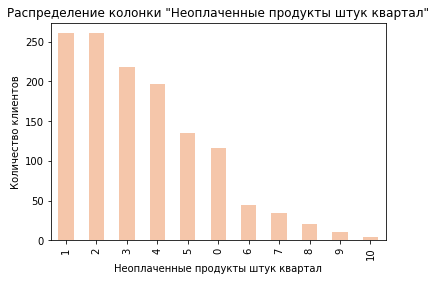

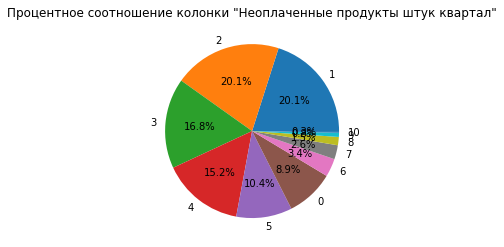

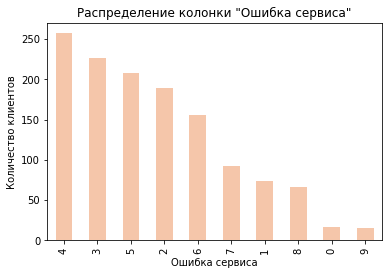

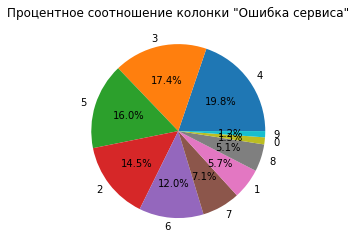

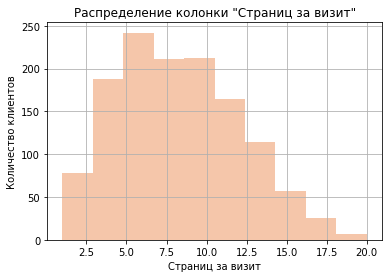

count    1300.000000
mean        8.176923
std         3.978126
min         1.000000
25%         5.000000
50%         8.000000
75%        11.000000
max        20.000000
Name: страниц_за_визит, dtype: float64


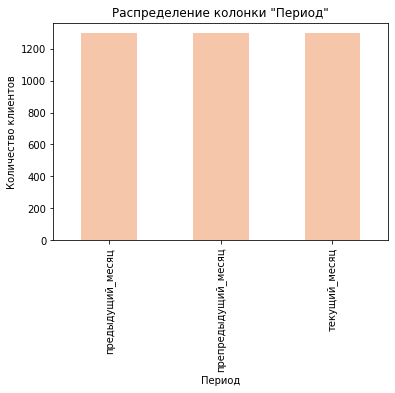

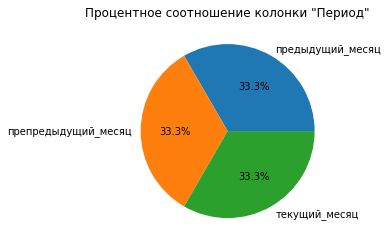

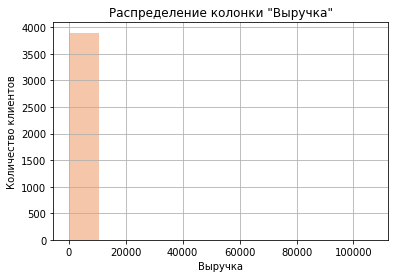

count      3900.000000
mean       5025.696051
std        1777.704104
min           0.000000
25%        4590.150000
50%        4957.500000
75%        5363.000000
max      106862.200000
Name: выручка, dtype: float64


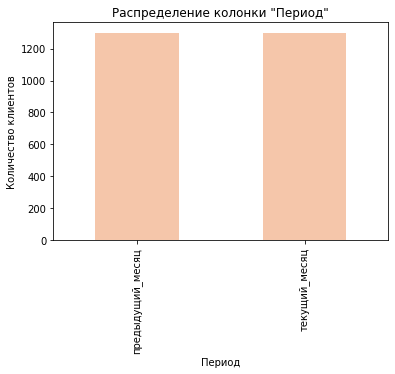

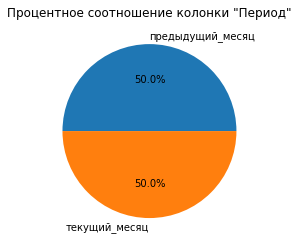

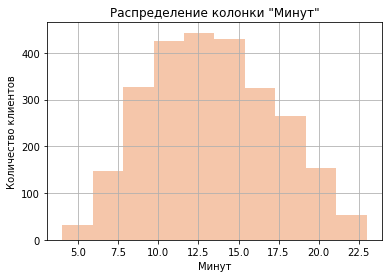

count    2600.000000
mean       13.336154
std         4.080198
min         4.000000
25%        10.000000
50%        13.000000
75%        16.000000
max        23.000000
Name: минут, dtype: float64


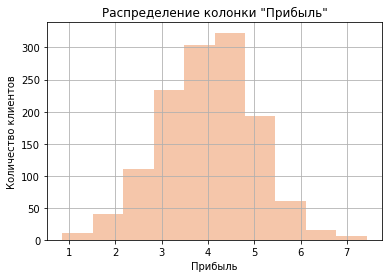

count    1300.000000
mean        3.996631
std         1.013722
min         0.860000
25%         3.300000
50%         4.045000
75%         4.670000
max         7.430000
Name: прибыль, dtype: float64


In [37]:
for data in data_list:
    for column in data.columns:
        analyze_distribution(data, column)

There is an outlier in the distribution of revenue from the market_money dataset on the graph; let's look at this column separately.
The graph shows an outlier of 106682 cu, which looks unrealistic compared to other values. Perhaps such a value does exist, but it describes a non-standard situation and interferes with the analysis, so it is better to remove it

In [38]:
market_money = market_money.query('выручка < 100000')

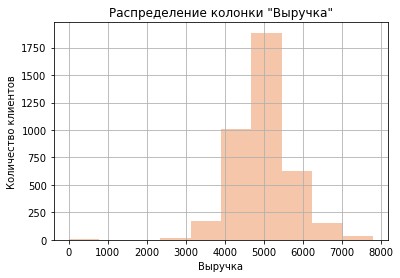

count    3899.00000
mean     4999.57743
std       706.99988
min         0.00000
25%      4590.10000
50%      4957.00000
75%      5363.00000
max      7799.40000
Name: выручка, dtype: float64


In [39]:
analyze_distribution(market_money, 'выручка')

Now the distribution is more similar to normal and although formally outliers remain in the data, they are not so “exotic” and do exist. The median and mean values ​​are almost equal, which also indicates the symmetry of the distribution

###Conclusion:
- there is a slight imbalance of classes in the target feature (62%/38%), it is weakly expressed, however, when dividing the data into a test and training set, we will take this into account and stratify the data;

- the majority of clients (71%) use the standard type of service;

- 74% of users agree to receive newsletters;

- marketing activity over the past 6 months is distributed close to normal, the median and mean are almost the same (4.2);

- in the current month, 51% of users received 4 marketing communications, approximately 24% each received 3 and 5 marketing communications;

- the duration distribution looks stable, close to normal, the median and mean are close in value, which indicates the symmetry of the data, there are no outliers, most of the users registered approximately 600 days ago;

- the distribution of promotional products is bimodal: for 75% of users, the share of promotional products in purchases is less than 30%, the median value of the share is 24%, however, there are users who buy exclusively promotional products (up to 99%), because of this, the average value is shifted upward;

- the most popular category of purchases is “goods for children” (25.4%), the least popular category is “kitchenware” (10.6%);

- the majority of users (75%) on average view from 2 to 4 categories per month (most often - 3 categories), a smaller percentage of users view 6 categories (6.6%), and only 8.2% view 1 category per month;

- the majority of users (over 70%) have from 1 to 5 unpaid items in their cart over the last 3 months;

- more than half of the users encountered service errors within 3 months ranging from 2 to 6, the most common number of errors was 4, which is quite a lot, the customer should pay attention to the technical operation of the site

- the distribution of pages per visit is similar to normal with a slight skew on the right, the average number of pages visited is almost equal to the median, which indicates the symmetry of the distribution, on average users view 8 pages per visit;

- in the revenue column, an outlier larger than 100 thousand cu was removed, on average the amount of revenue per 1 user for the period is about 5000 cu;

- the distribution of time spent on the site, in minutes, is normal and symmetrical, the mean and median are close in value and equal to approximately 13 minutes;

- the distribution of average monthly profit is normal, symmetrical, the average and median are close in value and equal to approximately 4 c.u.


In general, the data is normally distributed, does not have strong outliers or anomalies, and is quite ready for further work.

## Joining tables

In [40]:
# convert market_time into a pivot table, which will have a separate column for each period
market_time = market_time.pivot_table(index='id', columns='period', values='minutes')

In [41]:
# rename the columns
market_time = market_time.add_prefix('время_')

In [42]:
# convert market_money into a pivot table, which will have a separate column for each period
market_money = market_money.pivot_table(index='id', columns='period', values='выручка')

In [43]:
# rename the columns
market_money = market_money.add_prefix('выручка_')

In [44]:
# remove gaps in the market_money table
market_money = market_money.dropna()

In [45]:
# merging the market_file and market_time tables
market_all = market_file.join(market_time)

In [46]:
# we merge the tables market_all and market_money, we merge them using the “right” parameter,
# so that only the ids of users whose revenue is not equal to 0 for the period of the last 3 months remain
market_all = market_file.join(market_money, how='right')

In [47]:
market_all.head(10)
# Let's check the resulting table


,покупательская_активность,тип_сервиса,разрешить_сообщать,маркет_актив_6_мес,маркет_актив_тек_мес,длительность,акционные_покупки,популярная_категория,средний_просмотр_категорий_за_визит,неоплаченные_продукты_штук_квартал,ошибка_сервиса,страниц_за_визит,выручка_предыдущий_месяц,выручка_препредыдущий_месяц,выручка_текущий_месяц
id,,,,,,,,,,,,,,,
215348,Снизилась,премиум,да,3.4,5,121.0,0.00,Товары для детей,6,2,1,5.0,0.0,0.0,3293.1
215349,Снизилась,премиум,да,4.4,4,819.0,0.75,Товары для детей,4,4,2,5.0,5216.0,4472.0,4971.6
215350,Снизилась,стандарт,нет,4.9,3,539.0,0.14,Домашний текстиль,5,2,1,5.0,5457.5,4826.0,5058.4
215351,Снизилась,стандарт,да,3.2,5,896.0,0.99,Товары для детей,5,0,6,4.0,6158.0,4793.0,6610.4
215352,Снизилась,стандарт,нет,5.1,3,1064.0,0.94,Товары для детей,3,2,3,2.0,5807.5,4594.0,5872.5
215353,Снизилась,стандарт,да,3.3,4,762.0,0.26,Домашний текстиль,4,1,1,4.0,4738.5,5124.0,5388.5
215354,Снизилась,стандарт,да,5.1,3,431.0,0.23,Косметика и аксесуары,2,3,7,2.0,5685.0,4503.0,5869.6
215355,Снизилась,стандарт,нет,4.7,4,284.0,0.17,Товары для детей,5,1,6,4.0,3263.0,4749.0,3772.6
215356,Снизилась,стандарт,да,4.2,4,192.0,0.14,Косметика и аксесуары,2,2,1,3.0,4146.5,4433.0,4566.4


In [48]:
market_all = market_all.query(
        'выручка_предыдущий_месяц != 0 and выручка_препредыдущий_месяц != 0 and выручка_текущий_месяц != 0'
    )

In [49]:
market_all.shape

(1296, 15)

In [50]:
market_all.isna().sum()
# verifiable gap dataset


покупательская_активность              0
тип_сервиса                            0
разрешить_сообщать                     0
маркет_актив_6_мес                     0
маркет_актив_тек_мес                   0
длительность                           0
акционные_покупки                      0
популярная_категория                   0
средний_просмотр_категорий_за_визит    0
неоплаченные_продукты_штук_квартал     0
ошибка_сервиса                         0
страниц_за_визит                       0
выручка_предыдущий_месяц               0
выручка_препредыдущий_месяц            0
выручка_текущий_месяц                  0
dtype: int64

###Conclusion:
I combined the dataframes, leaving only users who made purchases every month for 3 months: the dataframe has 15 columns and 1299 rows, there are no gaps.

## Correlation data analysis

In [51]:
interval_cols = [
    'маркет_актив_6_мес', 
    'длительность', 
    'акционные_покупки', 
    'выручка_препредыдущий_месяц', 
    'выручка_предыдущий_месяц', 
    'выручка_текущий_месяц']

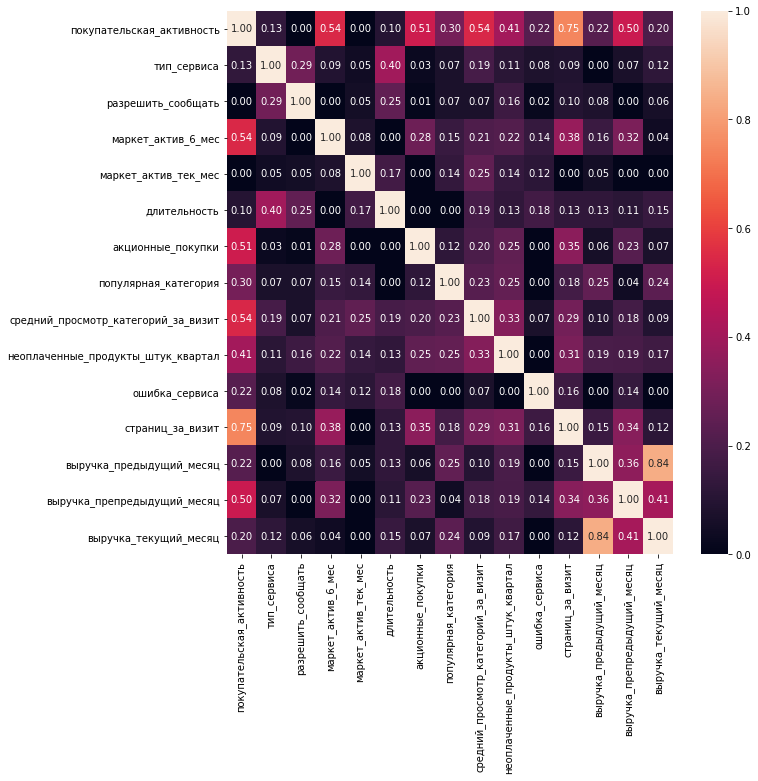

In [52]:
# Let's build a Pearson correlation matrix for quantitative characteristics
plt.figure(figsize=(10, 10))
sns.heatmap(market_all.phik_matrix(interval_cols=interval_cols), annot=True, fmt='.2f')
plt.show()

**Conclusion:** According to the phik correlation map, there is no multicollinearity among quantitative characteristics, all coefficients are less than 0.9

## Using pipelines

### Metric selection

It is important for the store to accurately predict customers whose purchasing activity has decreased in order to attract their attention in time with additional offers, discounts and promotions, that is, it is important to predict users whose class is 1 (activity has decreased). If customers with class 0 (previous level of activity) are assigned class 1, it will not be as expensive for the store than missing users with reduced activity, so you need to select recall as the main metric. However, it is worth controlling the level of precision so that it is not too low and we do not have too many FPs, since excessive attention to already active users can cause irritation and dissatisfaction, and also leads to costs. The f1_score metric will help us combine these 2 conditions.

### Using pipelines

In [53]:
# let's set constants
RANDOM_STATE = 42
TEST_SIZE = 0.25

In [54]:
# we divide the data into test and training samples, stratify the samples according to the target characteristic
X_train, X_test, y_train, y_test = train_test_split(
    market_all.drop(['покупательская_активность'], axis=1),
    (market_all['shopping_activity'] == 'Снизилась').astype('int'),
    test_size = TEST_SIZE, 
    random_state = RANDOM_STATE,
    stratify = market_all['shopping_activity'])

In [55]:
# let's split the dataframe columns according to processing method
ohe_columns = ['популярная_категория']
ord_columns = ['тип_сервиса', 'разрешить_сообщать']

In [56]:
# service type is the only categorical column that can be ranked, so you can use
# OrdinalEncoder
num_columns = X_train.select_dtypes(include='number').columns.to_list()

In [65]:
# creating a pipeline for preparing features from the ohe_columns list: filling gaps and OHE encoding
# SimpleImputer + OHE
ohe_pipe = Pipeline(
    [('simpleImputer_ohe', SimpleImputer(missing_values=np.nan, strategy='most_frequent')),
     ('ohe', OneHotEncoder(drop='first', handle_unknown='ignore'))
    ]
    )

In [87]:
# creating a pipeline for preparing features from the ord_columns list: filling gaps and Ordinal encoding
# SimpleImputer + OE
ord_pipe = Pipeline(
    [('simpleImputer_before_ord', SimpleImputer(missing_values=np.nan, strategy='most_frequent')),
     ('ord', OrdinalEncoder(
         categories=[
             ['да', 'нет'],
             ['стандарт', 'премиум']
                    ],
         handle_unknown='use_encoded_value', unknown_value=np.nan)),
     ('simpleImputer_after_ord', SimpleImputer(missing_values=np.nan, strategy='most_frequent'))
      ])

In [88]:
# creating a common pipeline for data preparation
data_preprocessor = ColumnTransformer(
    [('ohe', ohe_pipe, ohe_columns),
     ('ord', ord_pipe, ord_columns),
     ('num', StandardScaler(), num_columns)
    ]
)

In [89]:
# let's combine the pipeline for data preparation with model initialization
pipe_final = Pipeline([
    ('preprocessor', data_preprocessor),
    ('models',  DecisionTreeClassifier(random_state=RANDOM_STATE))
])

In [90]:
# create a list with hyperparameters for each model
param_grid = [
    # dictionary for the DecisionTreeClassifier() model
    {
        'models': [DecisionTreeClassifier(random_state=RANDOM_STATE)],
        'models__max_depth': range(2, 6),
        'models__min_samples_split': range(2, 6),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), RobustScaler()]  
    },
    
    # dictionary for the KNeighborsClassifier() model
    {
        'models': [KNeighborsClassifier()],
        'models__n_neighbors': range(2, 10),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), RobustScaler(), 'passthrough']   
    },

    # dictionary for the LogisticRegression() model
    {
        'models': [LogisticRegression(
            random_state=RANDOM_STATE, 
            solver='liblinear', 
            penalty='l1'
        )],
        'models__C': range(1, 6),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), RobustScaler(), 'passthrough']  
    },
     # dictionary for the SVC() model
    {
        'models': [SVC(random_state=RANDOM_STATE)],
        'models__kernel': ['linear', 'rbf', 'sigmoid'],
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), RobustScaler(),  'passthrough']
    }, 
     # dictionary for the SVC() model with poly core
    {
        'models': [SVC(random_state=RANDOM_STATE)],
        'models__kernel': ['poly'],
        'models__degree': range(1, 6),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), RobustScaler(), 'passthrough']
    }
]

In [91]:
randomized_search = RandomizedSearchCV(
    pipe_final,
    param_grid,
    cv=5,
    scoring='f1',
    random_state=RANDOM_STATE,
    n_jobs=-1,
    n_iter=30
)

In [92]:
randomized_search.fit(X_train, y_train)

In [93]:
best_pipe = randomized_search.best_estimator_
best_pipe
# we will derive the best model


In [94]:
randomized_search.best_score_
# Let's display the best value of the f1 metric


0.7883322332301657

In [95]:
y_pred = randomized_search.predict(X_test)
# Using the best model, we will predict the values ​​for X_test


In [ ]:
X_test

In [96]:
y_pred_proba = randomized_search.predict_proba(X_test)[:, 1]
# Using the best model, we will predict the probabilities of class membership for X_test


In [97]:
f1_score(y_test, y_pred)
# let's calculate f1 for y_pred


0.8103448275862069

In [98]:
recall_score(y_test, y_pred)
# let's calculate recall for y_pred


0.7642276422764228

In [99]:
precision_score(y_test, y_pred)
# let's calculate the precision for y_pred


0.8623853211009175

In [86]:
roc_auc_score(y_test, y_pred_proba)
# let's calculate roc_auc for y_pred


0.8996481009586215

### Checking the model for adequacy

In [107]:
# Let's create a DummyClassifier with different strategies and define f1_score for each
models = {
    "most_frequent": DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE),
    "stratified": DummyClassifier(strategy="stratified", random_state=RANDOM_STATE),
    "uniform": DummyClassifier(strategy="uniform", random_state=RANDOM_STATE),
    "constant=1": DummyClassifier(strategy="constant", constant=1, random_state=RANDOM_STATE),
}

for name, clf in models.items():
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    print(f1_score(y_test, y_pred))

0.0
0.37751004016064255
0.4
0.5503355704697986


All DummyClassifier models have a worse metric than our model, which means that it works better than constant models and it is advisable to use it

###Conclusion:
Using a pipeline and randomized search, I selected the best model and its hyperparameters - Logistic regression, with l1-regularization and C = 1. Its f1-measure for the training set turned out to be 0.80. Subsequently, I calculated f1_score, recall_score, precision_score, roc_auc_score for the test sample and they all gave good results:
 - f1 = 0.80, this means that the model does not have retraining;
 - recall = 0.76;
 - precision = 0.84;
 - roc_auc = 0.89
 
 This model has been tested for adequacy when compared with dummy models

## Feature importance analysis

In [108]:
best_pipe = randomized_search.best_estimator_  # Let's save the best Pipeline
preprocessor = best_pipe.named_steps['preprocessor'] # save Column Transformer with data preparation
model = best_pipe[-1] # save the pipeline for preparing models


In [109]:
feature_names = preprocessor.get_feature_names_out()

In [110]:
X_train_transformed = preprocessor.transform(X_train)

In [ ]:
shap_matrix = model.get_feature_importance(X, type="ShapValues")

In [ ]:
shap_values = shap_matrix[:, :-1]
base_value = shap_matrix[:, -1]

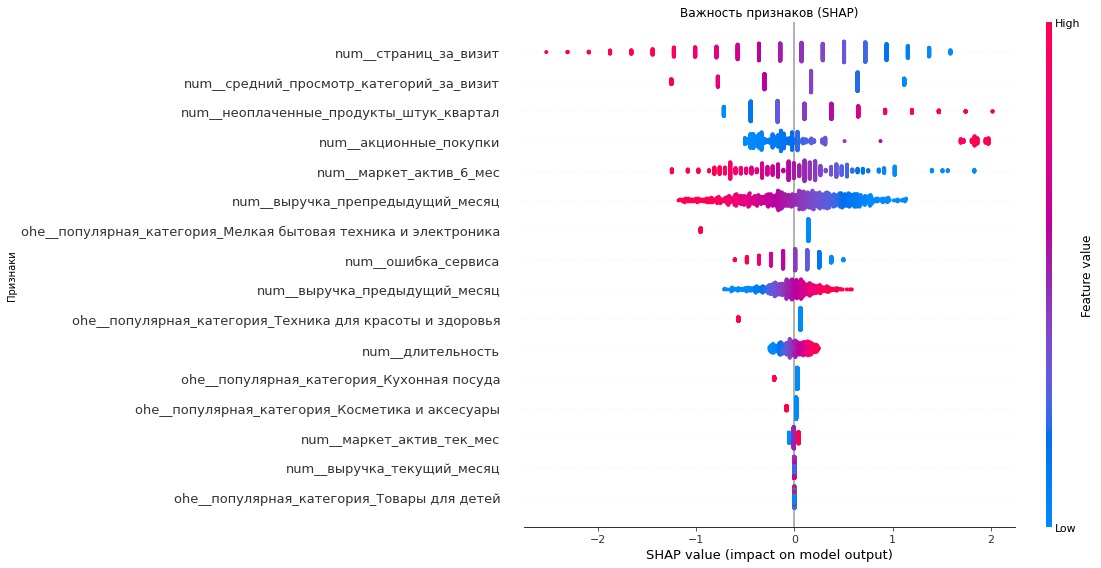

In [112]:
shap.summary_plot(
shap_values,
X_train_transformed,
feature_names=feature_names,
max_display=20,
plot_size=(16, 8),
show=False  
)

ax = plt.gca()
ax.set_title("Significance of Features (SHAP)")
ax.set_ylabel("Feature names")

plt.tight_layout()
plt.show()

### Conclusion:

*Little significant for the model* 
- service_type — the influence is weak and segmental.
- market_active_current_month - almost no contribution.
- popular_category_*: Kitchenware, Cosmetics and accessories, Products for children - individually almost “mute”
  
*Strongest influence on the target trait*:
- pages_per_visit - high values (red dots) are often to the left of zero → reduce the likelihood of a decrease;
- categories_per_visit - similar: more unique categories per visit → same level of activity;
- revenue_previous_month - generally “protects” from decline (red is more often on the left), but non-monotonicity/segments are visible;
- revenue_previous_month - a high value of the attribute leads to a decrease in activity, this may be due to the “seasonality” of purchases, for example, the user buys a product that needs to be updated once every 2 months or decides to save money this month because he spent the previous month;
- market_active_6_months - mixed effect: there are clusters on both the left and the right; the impact depends on combinations with other features (for example, service_type, promotional_purchases);
- promotional_purchases - a noticeable right tail (red on the right): high promotional activity is associated with the risk of a subsequent decline;
- unpaid_products_items_quarter - high values ​​pull the forecast to the right → increasing the probability of a decrease;
- duration - a predominantly protective effect at reasonable values, but mixed at extremes.

The customer needs to introduce various features to increase page views and category dependencies, for example, offering recommendations based on previous purchases or shopping cart. The same applies to unpaid products in the cart; the more there are, the longer the buyer postpones their purchase; you need to encourage the purchase of goods at the moment with various notifications and discounts. Marketing activity works well in the long term, but in the current month it has practically no effect on activity; the customer should continue marketing interaction with users every month. The higher the share of promotional purchases, the higher the likelihood of a decrease in activity - this may be due to the fact that some users make purchases exclusively on discounts; for such buyers, you can introduce exclusive offers; as a rule, a discount of even a couple of percent can motivate them to make a purchase.

## User segmentation

### User segmentation

It is especially important for the customer to retain users who bring in a lot of revenue; such users should be given attention first if their activity decreases. Let's combine the market_all and money tables and add the "profitability_level" column to the final dataframe, which will take the value "high" if the profit from the buyer is above the median, and "low" if below. We will do the same in the column with “risk_of_decrease_activity”: assign the value “high” if purchasing_activity has decreased and “low” if it has remained at the same level. After that, in the “segment” column, we assign each buyer one of 4 categories: “high-high”, “high-low”, “low-high”, “low-low”, where the first characteristic relates to purchasing activity, and the second to the level of profitability

In [114]:
market_all = market_all.join(money, how='left')

In [115]:
# adding columns with the level of profitability and risk of decline in activity
market_all['profit_level'] = np.where(
    market_all['profit'] >= market_all['profit'].median(), 
    "высокий", 
    "низкий"
)

market_all['risk_of_decrease_activity'] =  np.where(
    market_all['shopping_activity'] == 'Снизилась', 
    "высокий", 
    "низкий"
)

In [116]:
# add a column with a segment
market_all['segment'] = market_all['profit_level'] + '-' + market_all['risk_of_decrease_activity']

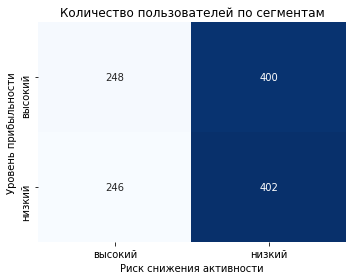

In [117]:
# Let's build a heat map by segments
pivot_market = (market_all.pivot_table(index='profit_level', columns='risk_of_decrease_activity',
                            values='shopping_activity', aggfunc="count", fill_value=0)
               .sort_index().sort_index(axis=1))

plt.figure(figsize=(5,4))
ax = sns.heatmap(pivot_market, annot=True, fmt='.0f', cmap='Blues', cbar=False)
ax.set_title('Number of users by segment')
ax.set_xlabel('Risk of decreased activity')
ax.set_ylabel('Profitability level')
plt.tight_layout()
plt.show()

Users with a high risk of decline in activity were divided almost equally between high and low levels of profitability. As a segment to study, we will consider the “high-high” segment, since its retention is most profitable for the store.

### High-high segment

In [118]:
# Let's create a dataframe for the "high-high" segment
market_high_high = market_all.query('сегмент == "высокий-высокий"')

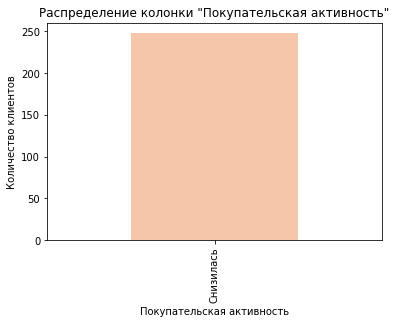

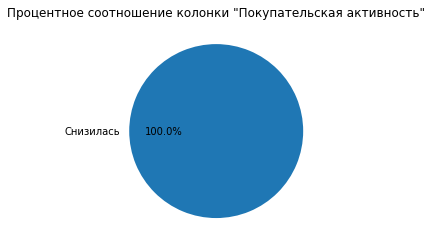

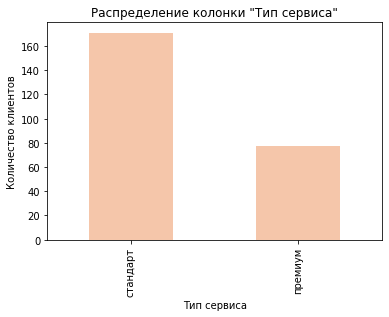

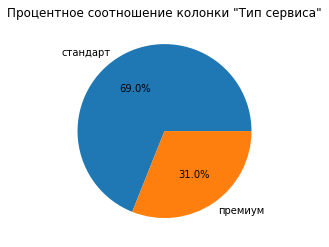

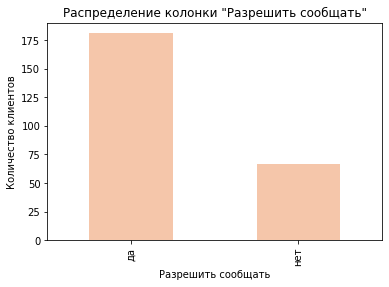

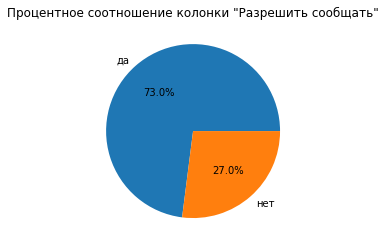

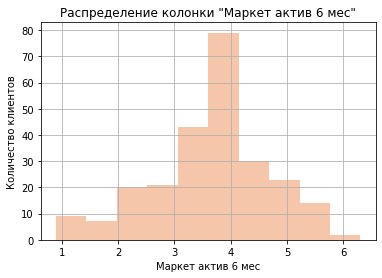

count    248.000000
mean       3.706048
std        1.030862
min        0.900000
25%        3.100000
50%        3.900000
75%        4.225000
max        6.300000
Name: маркет_актив_6_мес, dtype: float64


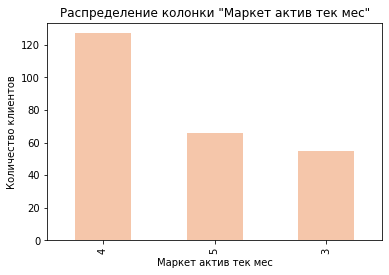

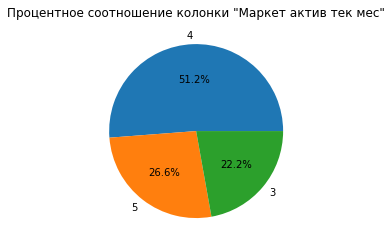

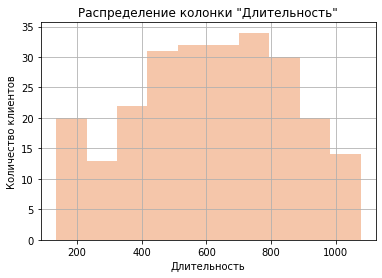

count     248.000000
mean      613.201613
std       239.864148
min       136.000000
25%       446.750000
50%       623.000000
75%       805.250000
max      1076.000000
Name: длительность, dtype: float64


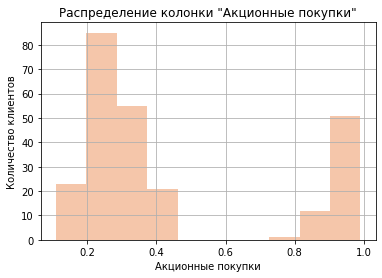

count    248.000000
mean       0.445121
std        0.300504
min        0.110000
25%        0.240000
50%        0.300000
75%        0.890000
max        0.990000
Name: акционные_покупки, dtype: float64


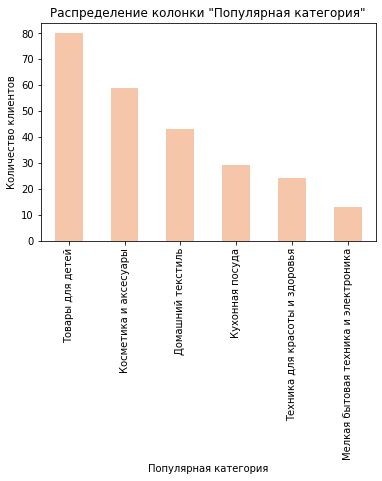

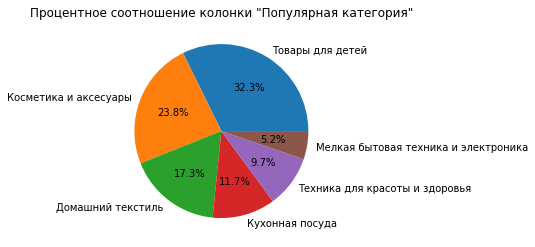

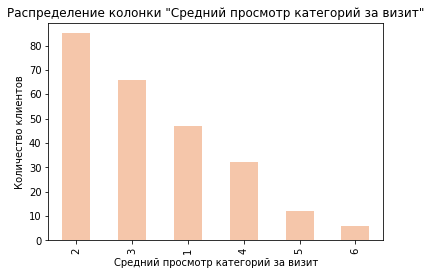

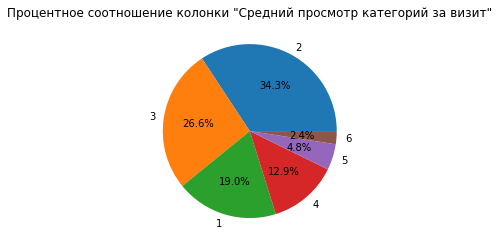

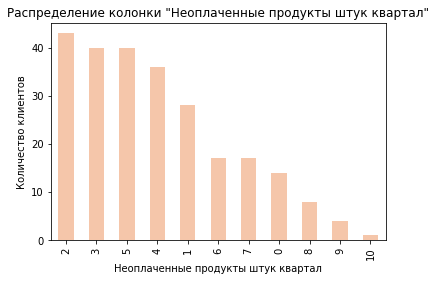

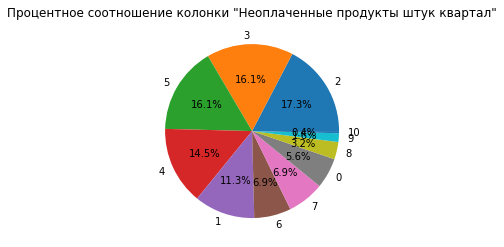

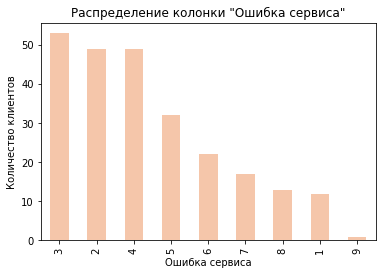

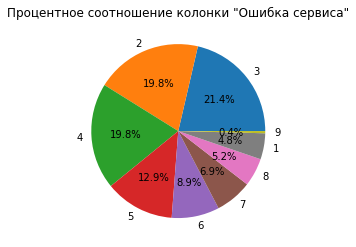

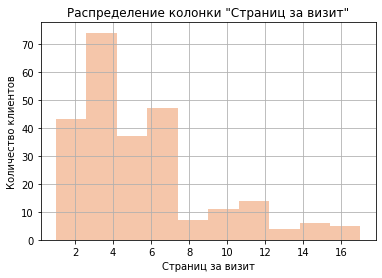

count    248.000000
mean       5.504032
std        3.483911
min        1.000000
25%        3.000000
50%        5.000000
75%        7.000000
max       17.000000
Name: страниц_за_визит, dtype: float64


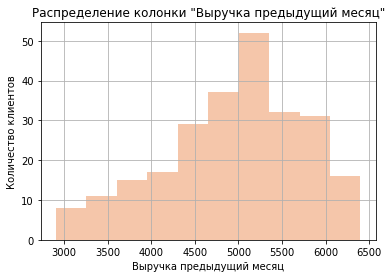

count     248.000000
mean     4947.274194
std       791.624890
min      2909.000000
25%      4460.125000
50%      5033.250000
75%      5555.125000
max      6399.500000
Name: выручка_предыдущий_месяц, dtype: float64


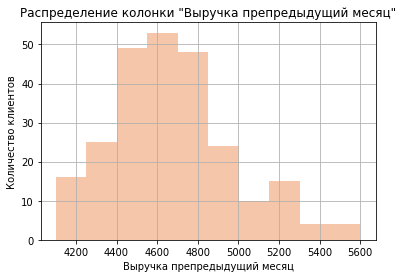

count     248.000000
mean     4675.560484
std       300.923323
min      4102.000000
25%      4466.750000
50%      4659.000000
75%      4826.250000
max      5601.000000
Name: выручка_препредыдущий_месяц, dtype: float64


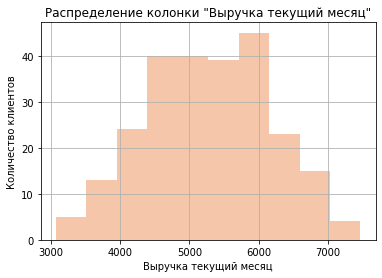

count     248.000000
mean     5277.489919
std       888.165195
min      3078.300000
25%      4596.200000
50%      5296.400000
75%      5913.200000
max      7467.900000
Name: выручка_текущий_месяц, dtype: float64


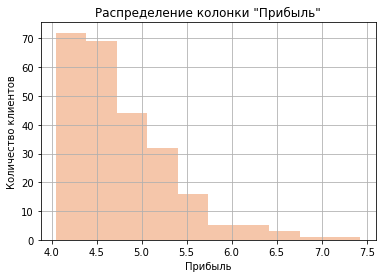

count    248.000000
mean       4.777137
std        0.581369
min        4.050000
25%        4.320000
50%        4.640000
75%        5.075000
max        7.430000
Name: прибыль, dtype: float64


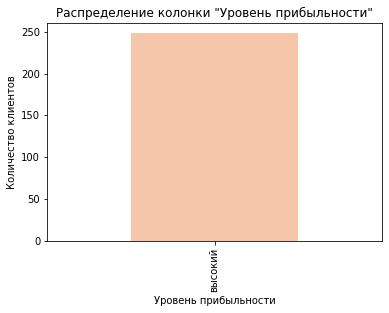

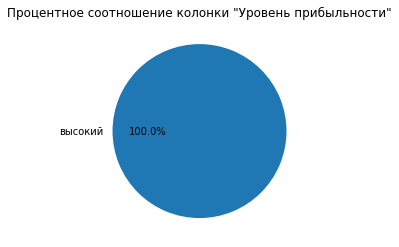

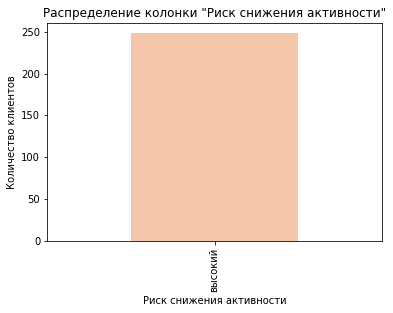

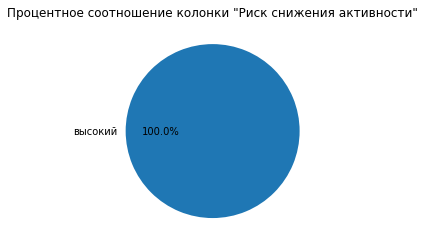

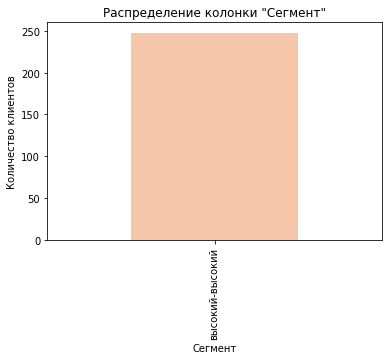

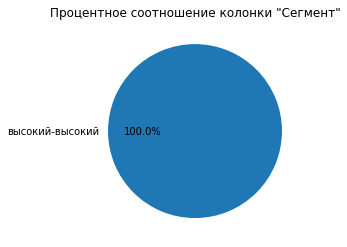

In [119]:
for column in market_high_high.columns:
    analyze_distribution(market_high_high, column)

### Conclusion and recommendations for the “high-high” segment
The distribution graphs of characteristics for the user segment with a high probability of a decrease in purchasing activity and the highest profitability show the following facts:
- distributions by type of service, message resolution, marketing activity in the current month, duration of stay on the site, share of promotional purchases practically do not differ from the distribution of the same characteristics in the general dataset;
- marketing activity is slightly reduced compared to the general dataset (on average 3.7 instead of 4.2);
- the distribution of popular categories differs from the distribution in the general dataset: products for children are still in first place, but their share is larger (32% instead of 25%), also the majority are purchases for the home, for yourself (beauty and health), in last place for such users are small household appliances;
- most users view from 1 to 3 categories per visit
- the number of unpaid products in the cart mostly ranges from 2 to 5;
- users of the segment mainly encounter service errors ranging from 2 to 6, only a very small part did not encounter errors at all; 
- users in this segment view about 5 pages per visit, while the average number of pages per visit for all users is 8;
- over the last quarter, the average monthly revenue from these users averaged more than $4,000

Based on these facts, we can describe the portrait of such users as follows:
These are people who do not spend much time on the site, come only for business and clearly do not skimp on their children, beauty and health. Such users may be put off by service errors, since such people tend to value their comfort, given that some of them encountered 6 or more errors per quarter, this is an important factor that the customer needs to correct. From the analysis of features using the SHAP method, we found that the “pages_per_visit” and “categories_per_visit” columns have the greatest impact on purchasing activity; users in the “high-high” segment have on average less of these features than users from the general dataset. Increasing these characteristics can be used as one of the ways to retain customers in this segment: offer the most interesting categories to the user immediately when they get to the site (products for children, beauty and health), it is important to correctly track and predict the products they like, since judging by the number of pages viewed, these users do not tend to spend a lot of time scrolling. You should also take the path of reducing unpaid items in the cart, remind about them or offer similar ones. If an item remains unpaid in the cart, it means there are some doubts about it, possibly related to the price, in which case promotions and discounts will come to the rescue.

##Conclusion:
Problem
   
   We solve an applied business problem: to proactively find clients at risk of decreased purchasing activity (class 1) in order to return them in a timely manner with attention, offers and service. The main thing for us is not to miss those who are leaving, so recall is a priority with reasonable precision control; to compare models, I used F1 as a balance between these metrics.

Data and preprocessing
Briefly about data purity and what I did:
- Changed the column names to snake_case, eliminated implicit duplicates in the service_type and a typo in the period, corrected the profit format (comma → dot, float type).
- EDA showed a moderate imbalance of classes 62%/38% - taken into account by stratification. In general, the distributions are calm, without strong anomalies; One extreme outlier in revenue >100k was removed.
- Behavior picture: 71% on standard service; 74% agree to newsletters; for 6 months, market activity is close to normal (avg.=med.=~4.2); pages per visit - about 8; time on site ~13 minutes; average revenue per user ~$5000; the share of promotional purchases is bimodal (there are “discount hunters”).
- Combined sources into a showcase and left users with purchases for each of the three months: 1299 lines, 15 signs, no gaps.
- The phik correlation did not reveal multicollinearity (|r| < 0.9) - it’s convenient to work with.

Finding the best model
   I assembled a single ML pipeline (feature preparation → model), went through several algorithms, and used RandomizedSearch for hyperparameters. The models were compared using F1 with a mandatory recall/precision check. Validation - with stratification. Essentially, we were looking not just for an “accurate” model, but for a “useful” model to hold.

Best model
   Interpretable Logistic Regression (L1, C=1) won.
- Test: F1 = 0.80, Recall = 0.76, Precision = 0.84, ROC AUC = 0.89.
- Retraining is not visible (F1 on train is also 0.80). The model is stable and understandable to business - a big plus for implementation.

Conclusions on the importance of features:
- “Defenders” from reduction: pages_per_visit, categories_per_visit, revenue_previous_month, duration (within reasonable limits). If the client looks deeper and wider, the likelihood of a fall is lower.
- Risk factors: a high proportion of promotional purchases, many unpaid items for the quarter, as well as “seasonality” after spending in the previous month.
- Weak influence: service_type, market_active_current_month, certain popular categories.
  Practically: regular market activity works for a long time, but “one-time bursts” of the current month hardly move the needle; Managing session behavior and working with the shopping cart provides more benefits.

Selected segment and offerings (“high risk” × “high profitability”)
   Whom do we hold the tightest:
- These users are valuable, but spend little time in session: ~5 pages per visit (vs. 8 on average) and 1-3 categories.
- More often they encounter errors (2–6 per quarter) and keep 2–5 unpaid items.
- More interest in “products for children” (≈32%), “for home” and “beauty and health” are noticeable.
- Market activity is slightly lower than overall (cf. 3.7 vs. 4.2). Average monthly revenue for the quarter is >4000 USD.

Ways to work with a segment:
- We will prioritize the elimination of errors in key scenarios (search → card → cart → payment). Valuable clients should not “break the route.”
- Making the first screen smarter: personal blocks with priority categories (children, beauty and health), shortcuts and “continue viewing”, fewer clicks - more relevance.
- We work with the shopping cart: trigger reminders, time-limited offers, neat coupons, notifications about price reductions and available alternative products, bundles to remove price doubts.
- We keep “discount hunters” without blurring the margin: small but personal discounts, early access to sales.
- Communicate wisely: we maintain regularity (long-term effect), the goal is not just to “reach out”, but to “get in.”

Bottom line
We prepared a clean, consistent showcase (1299×15), took into account the imbalance and obtained a “live” interpretable model that confidently finds customers with downside risk (F1=0.80, ROC AUC=0.89) and supports the main business priority - high recall. The key to retention is not endless emails, but reduced friction and personalized relevance: fewer errors, a smarter first screen, smart cart mechanics and targeted discounts. This way we don’t just predict risk, but change behavior – and retain those who are most expensive to lose.